# Linear dataset

Questions:

+ How can we generate a random number to use as the centre value or the chance of success?
+ How can we generate discrete data with six categories, not just two?
+ How can we generate data that's completely random?

## AIM
* To generate random data
* To plot the generated data

## Code setup

In [25]:
import pandas as pd
import numpy as np
import random as rn
import matplotlib.pyplot as plt

Use this many patients:

In [26]:
num_samples = 1000

Generate random values for continuous data:

In [27]:
rn.seed(42)
m = 4.0  # centre value
np.random.seed(42)#put random seed before generating any data 
W0 = np.random.normal(m, 1, num_samples)

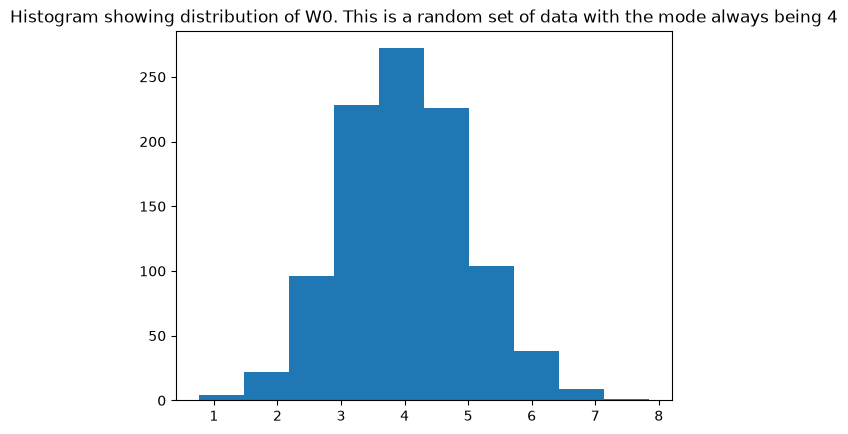

In [28]:
plt.hist(W0)
plt.title("Histogram showing distribution of W0. This is a random set of data with the mode always being 4")
plt.show()

Making a random centre value to then generate 1000 random numbers

In [29]:
rn.seed(42)
n= rn.random()
np.random.seed(42)
W1 = np.random.normal(n, 1, num_samples)

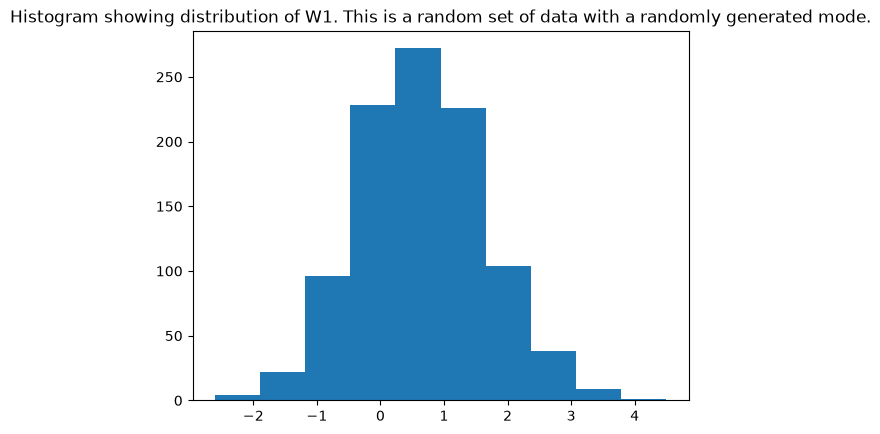

In [30]:
plt.hist(W1)
plt.title("Histogram showing distribution of W1. This is a random set of data with a randomly generated mode.")
plt.show()

Generate random values for discrete data:

In [31]:
p = 0.7  # chance of success
np.random.seed(42)
Z0 = np.random.binomial(1, p, num_samples)

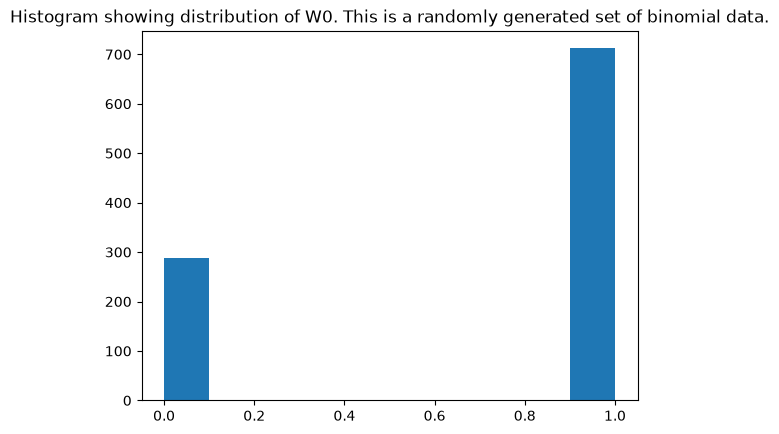

In [32]:
plt.hist(Z0)
plt.title("Histogram showing distribution of W0. This is a randomly generated set of binomial data.")
plt.show()

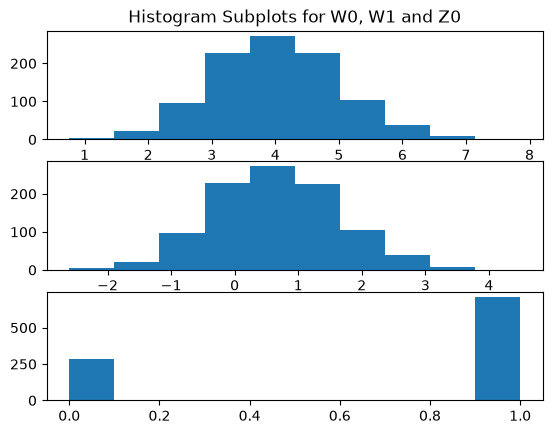

In [33]:
fig,axs=plt.subplots(3)#1.FIGURE
for i, a in enumerate([W0,W1,Z0]):#2.AXES
    axs[i].hist(a)
axs[0].set_title("Histogram Subplots for W0, W1 and Z0")#used[0] because when using [i] it remembers the last value which is 2
plt.show()

Generate random values for 6 different categories of data (eg: MRS scale)

In [34]:
abc=[0,1,2,3,4,5,6]
np.random.seed(42)
Z1=np.random.choice(abc,1000,p=[0.35,0.20,0.18,0.15,0.07,0.05,0.0])

In [35]:
df_z=pd.Series(Z1)
df_z.value_counts()

0    365
1    194
2    180
3    137
4     78
5     46
Name: count, dtype: int64

In [36]:
counts=list(df_z.value_counts())
#making a list of value counts to use as height

In [37]:
df_z.value_counts().index
#taking out index as a series

Index([0, 1, 2, 3, 4, 5], dtype='int64')

<function matplotlib.pyplot.show(close=None, block=None)>

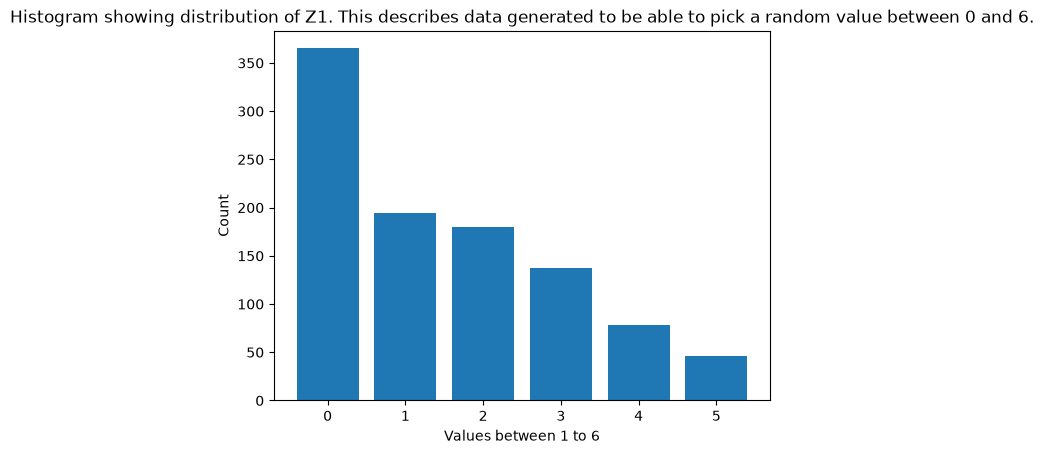

In [38]:
plt.bar(df_z.value_counts().index,counts)
plt.title("Histogram showing distribution of Z1. This describes data generated to be able to pick a random value between 0 and 6.")
plt.xlabel("Values between 1 to 6")
plt.ylabel("Count")
plt.show

Making a set of random data for triangular histogram

In [39]:
W2=np.random.triangular(-5,0,10,num_samples)
np.random.seed(42)

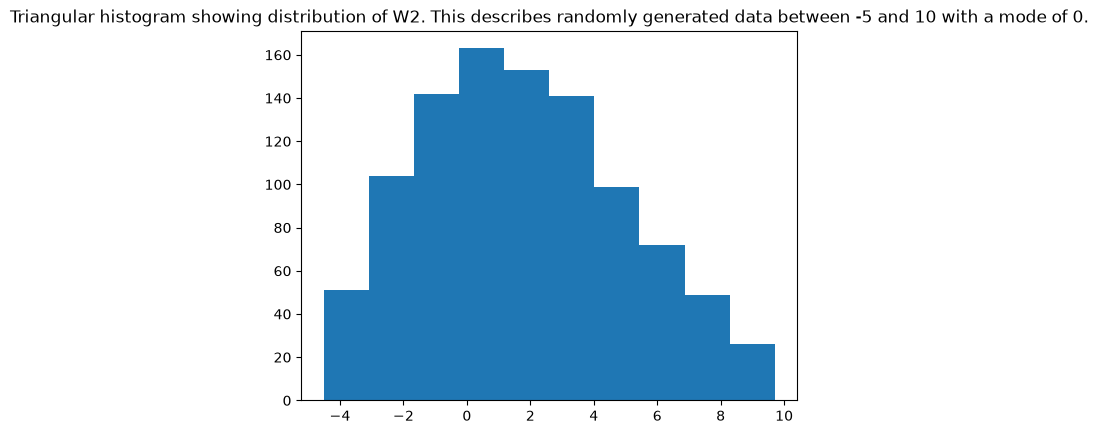

In [40]:
plt.hist(W2)
plt.title("Triangular histogram showing distribution of W2. This describes randomly generated data between -5 and 10 with a mode of 0.")
plt.show()

Weibull data

In [41]:
W3=np.random.weibull(50,1000)
np.random.seed(42)

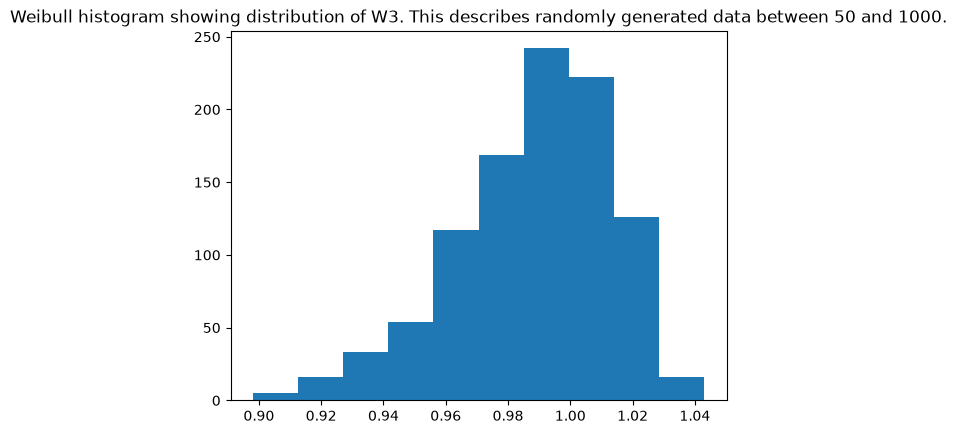

In [42]:
plt.hist(W3)
plt.title("Weibull histogram showing distribution of W3. This describes randomly generated data between 50 and 1000.")
plt.show()

Poisson data

In [43]:
np.random.seed(42)
W4= np.random.poisson(5,num_samples)

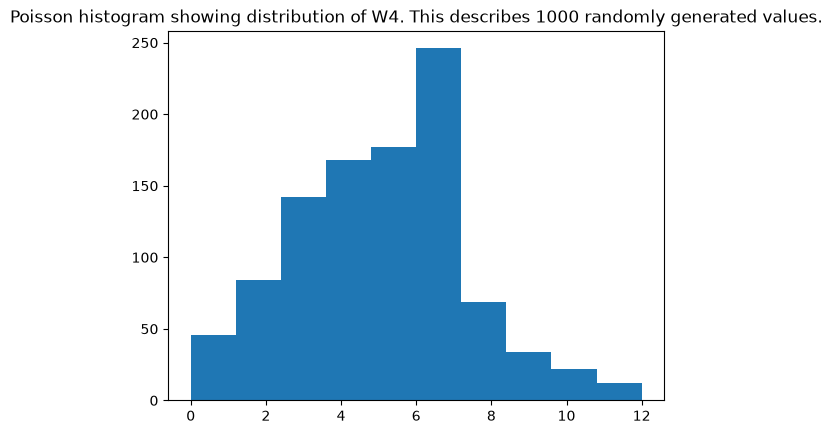

In [44]:
plt.hist(W4)
plt.title("Poisson histogram showing distribution of W4. This describes 1000 randomly generated values.")
plt.show()

Making a dataframe with W0, W1, W2, W3, W4, Z0 and Z1

In [49]:
df=pd.DataFrame([W0, W1, Z0, Z1, W2, W3, W4])
df.index=["Normal 1","Normal 2","Binomial","1 in 6","Triangular","Weibull","Poisson"]

In [50]:
df_a=df.transpose()
df_a

,Normal 1,Normal 2,Binomial,1 in 6,Triangular,Weibull,Poisson
0,4.496714,1.136141,1.0,1.0,-1.273746,0.984982,5.0
1,3.861736,0.501162,0.0,5.0,1.710557,1.022284,4.0
2,4.647689,1.287115,0.0,3.0,5.634439,1.005518,4.0
3,5.523030,2.162457,1.0,2.0,3.662314,0.998180,5.0
4,3.765847,0.405273,1.0,0.0,4.613366,0.965139,5.0
...,...,...,...,...,...,...,...
995,3.718900,0.358327,1.0,0.0,2.826666,0.954223,3.0
996,5.797687,2.437113,0.0,4.0,7.448960,1.018435,9.0
997,4.640843,1.280270,1.0,0.0,-2.725830,0.962397,8.0
998,3.428821,0.068248,0.0,5.0,-2.931400,1.022219,4.0


Subplot for all 6 columns

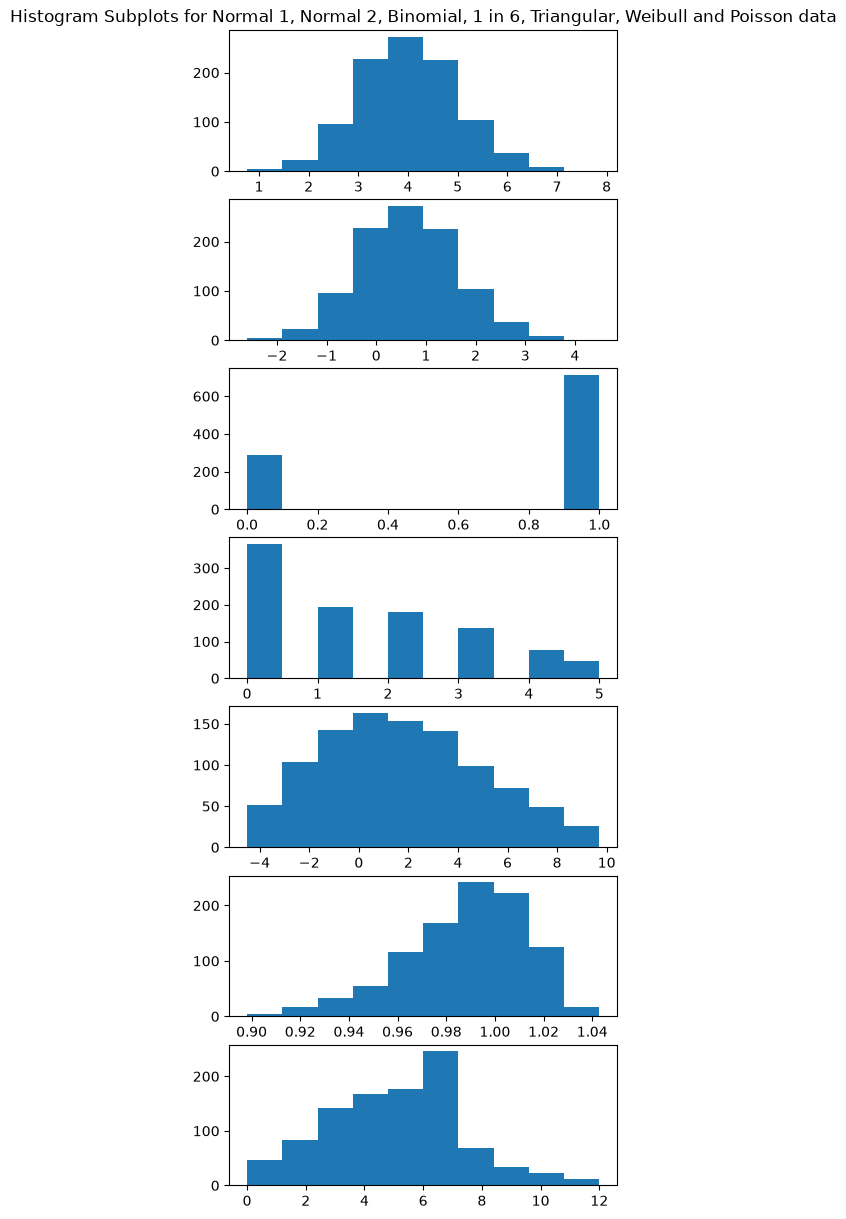

In [51]:
fig,axs=plt.subplots(7, figsize=(5,15))
for i, a in enumerate(df_a.columns):
    axs[i].hist(df_a[a])
axs[0].set_title("Histogram Subplots for Normal 1, Normal 2, Binomial, 1 in 6, Triangular, Weibull and Poisson data")
plt.show()

New way to generate random data

In [48]:
from numpy.random import Generator, PCG64
rng = Generator(PCG64())
rng.standard_normal((num_samples))

array([-7.86934820e-01,  7.40260756e-01, -9.14046473e-01, -1.23108600e+00,
        5.97693498e-01, -1.55581981e+00, -1.64974704e+00, -1.77415341e-01,
       -6.72753111e-01,  2.00284973e+00,  4.82213006e-01, -1.04525428e+00,
        1.23332398e+00,  1.37272429e-01, -1.11706195e-01, -7.10971309e-02,
        1.24772015e+00, -1.38241856e-01,  5.33980826e-01,  1.61467811e+00,
        1.03849632e+00,  1.94309729e+00,  4.15912590e-01,  1.73337377e+00,
        2.29285375e-01,  7.55938538e-01,  2.70236699e-03,  3.86437725e-01,
        1.09612245e+00,  7.21401397e-01, -1.54181835e+00,  4.53684267e-01,
       -5.40385647e-01,  1.88773902e+00,  6.79016811e-01, -4.84783696e-01,
        5.61085279e-01, -1.07532792e+00,  6.97076785e-03, -2.88522246e-01,
       -1.01661700e+00,  1.45388025e+00, -1.35237788e-01,  1.42346515e+00,
        1.37568898e-01,  1.94850884e-01,  1.84389295e-01,  3.18615752e-01,
       -8.07894088e-01,  9.09540740e-01,  8.40316877e-02, -1.85339807e-01,
        1.66512790e+00,  